# MVP v3: Comparing External KG Sources for Drug-Disease Link Prediction

**Research question:** Which external knowledge sources add the most predictive signal on top of a PrimeKG base?

**Five graph configurations:**
| Graph | Contents |
|-------|----------|
| A | PrimeKG 1-hop base (same as v2 Graph B) |
| B | A + DISEASES (Jensen Lab, disease-gene) |
| C | A + Reactome (NCBI gene → pathway) |
| D | A + PharmGKB (drug/chemical–gene) |
| E | A + DISEASES + Reactome + PharmGKB (all three) |

**Evaluation (identical to v2):** 5-fold StratifiedKFold CV + LODO CV, RandomForest with heuristic, Node2Vec, and combined features.


## 1. Setup & Imports

In [1]:
# Install any missing packages (Colab already has most)
import subprocess, sys
pkgs = ["gensim", "tqdm"]
for pkg in pkgs:
    try:
        __import__(pkg)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])
print("Packages ready.")


Packages ready.


In [2]:
import pandas as pd
import numpy as np
import networkx as nx
from sklearn.model_selection import cross_val_score, StratifiedKFold, train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, roc_curve, auc
from gensim.models import Word2Vec
import random
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import os, sys, time, warnings, pickle, io, zipfile, requests
warnings.filterwarnings('ignore')
np.random.seed(42)
random.seed(42)

RESULTS = {}
print("Imports OK")


Imports OK


## 2. Load PrimeKG

Upload `kg.csv` to the `data/` folder in your Colab session, or mount Google Drive and adjust `DATA_PATH`.


In [3]:
# ── Option A: Mount Google Drive ──────────────────────────────────────────
# from google.colab import drive
# drive.mount('/content/drive')
# DATA_PATH = '/content/drive/MyDrive/disease-drug-networks/data/kg.csv'

# ── Option B: Upload from local machine ───────────────────────────────────
# from google.colab import files
# uploaded = files.upload()   # select kg.csv
# DATA_PATH = 'kg.csv'

# ── Option C: Already in data/ folder ─────────────────────────────────────
DATA_PATH = 'data/kg.csv'
os.makedirs('data', exist_ok=True)

t0 = time.time()
print("Loading PrimeKG...")
df = pd.read_csv(DATA_PATH, low_memory=False)
print(f"Loaded: {df.shape[0]:,} edges in {time.time()-t0:.1f}s")

# Normalize drug-disease edges
dd_mask = (((df['x_type']=='drug')&(df['y_type']=='disease'))|
           ((df['x_type']=='disease')&(df['y_type']=='drug')))
dd_df = df[dd_mask].copy()
is_drug_x = dd_df['x_type'] == 'drug'
dd_norm = pd.DataFrame({
    'drug_id':      np.where(is_drug_x, dd_df['x_id'].values,   dd_df['y_id'].values),
    'drug_name':    np.where(is_drug_x, dd_df['x_name'].values, dd_df['y_name'].values),
    'disease_id':   np.where(is_drug_x, dd_df['y_id'].values,   dd_df['x_id'].values),
    'disease_name': np.where(is_drug_x, dd_df['y_name'].values, dd_df['x_name'].values),
    'relation':     dd_df['relation'].values
})

contra   = dd_norm[dd_norm['relation']=='contraindication']
indica   = dd_norm[dd_norm['relation']=='indication']
off_label = dd_norm[dd_norm['relation']=='off-label use']
print(f"Contra: {len(contra):,}  Indica: {len(indica):,}  Off-label: {len(off_label):,}")


Loading PrimeKG...
Loaded: 8,100,498 edges in 23.9s
Contra: 61,350  Indica: 18,776  Off-label: 5,136


## 3. Build Dataset

Same selection as v2: 328 balanced diseases, top-1000 drugs, contraindication=1 vs indication=0.  
Target edges (drug, disease pairs in the dataset) are excluded from all graphs to prevent leakage.


In [4]:
# Select diseases with both contra & indication (≥20% minority class)
both = set(contra['disease_id']) & set(indica['disease_id'])

dc = contra[contra['disease_id'].isin(both)].groupby(['disease_id','disease_name']).size().reset_index(name='contra_count')
di = indica[indica['disease_id'].isin(both)].groupby(['disease_id','disease_name']).size().reset_index(name='indica_count')
dcounts = dc.merge(di[['disease_id','indica_count']], on='disease_id')
dcounts['total'] = dcounts['contra_count'] + dcounts['indica_count']
dcounts['bal']   = dcounts[['contra_count','indica_count']].min(axis=1) / dcounts[['contra_count','indica_count']].max(axis=1)
sel_dis     = dcounts[dcounts['bal']>=0.2].sort_values('total', ascending=False).head(328)
sel_dis_ids = sel_dis['disease_id'].tolist()

# Top-1000 drugs
sc = contra[contra['disease_id'].isin(sel_dis_ids)]
si = indica[indica['disease_id'].isin(sel_dis_ids)]
drc = sc.groupby(['drug_id','drug_name']).size().reset_index(name='c')
dri = si.groupby(['drug_id','drug_name']).size().reset_index(name='i')
drug_c = drc.merge(dri[['drug_id','i']], on='drug_id', how='outer').fillna(0)
drug_c['total'] = drug_c['c'] + drug_c['i']
sel_drugs    = drug_c.sort_values('total', ascending=False).head(1000)
sel_drug_ids = sel_drugs['drug_id'].tolist()

# Dataset
pos = contra[(contra['disease_id'].isin(sel_dis_ids))&(contra['drug_id'].isin(sel_drug_ids))].copy()
neg = indica[(indica['disease_id'].isin(sel_dis_ids))&(indica['drug_id'].isin(sel_drug_ids))].copy()
pos['label'] = 1; neg['label'] = 0
df_dataset = pd.concat([pos, neg], ignore_index=True)
y = df_dataset['label'].values
N_DISEASES = len(sel_dis_ids); N_DRUGS = len(sel_drug_ids)
print(f"{N_DISEASES} diseases, {N_DRUGS} drugs")
print(f"Dataset: {len(df_dataset)} samples  ({len(pos)} contra, {len(neg)} indica)")

# Target edges to exclude from all graphs
target_edges = set()
for d, dis in zip(df_dataset['drug_id'].astype(str), df_dataset['disease_id'].astype(str)):
    target_edges.add((d, dis)); target_edges.add((dis, d))
print(f"Target edge pairs excluded from graphs: {len(target_edges)//2:,}")


328 diseases, 1000 drugs
Dataset: 14824 samples  (9574 contra, 5250 indica)
Target edge pairs excluded from graphs: 7,384


## 4. Download External Data Sources

Downloads are cached to `data/`. If a download fails, the corresponding graph silently equals Graph A.


In [5]:
# ── DISEASES (Jensen Lab) ─────────────────────────────────────────────────
DISEASES_PATH = "data/diseases_knowledge.tsv"
if not os.path.exists(DISEASES_PATH):
    print("Downloading DISEASES database...")
    try:
        resp = requests.get("https://download.jensenlab.org/human_disease_knowledge_filtered.tsv", timeout=60)
        resp.raise_for_status()
        with open(DISEASES_PATH, 'w', encoding='utf-8') as f:
            f.write(resp.text)
        print(f"  Saved: {DISEASES_PATH}  ({os.path.getsize(DISEASES_PATH)//1024} KB)")
    except Exception as e:
        print(f"  DISEASES download failed: {e}")
        DISEASES_PATH = None
else:
    print(f"Already have: {DISEASES_PATH}  ({os.path.getsize(DISEASES_PATH)//1024} KB)")


Already have: data/diseases_knowledge.tsv  (588 KB)


In [6]:
# ── Reactome ──────────────────────────────────────────────────────────────
REACTOME_PATH = "data/reactome_ncbi.txt"
if not os.path.exists(REACTOME_PATH):
    print("Downloading Reactome NCBI2Reactome...")
    try:
        resp = requests.get("https://reactome.org/download/current/NCBI2Reactome_All_Levels.txt", timeout=120)
        resp.raise_for_status()
        with open(REACTOME_PATH, 'w', encoding='utf-8') as f:
            f.write(resp.text)
        print(f"  Saved: {REACTOME_PATH}  ({os.path.getsize(REACTOME_PATH)//1024} KB)")
    except Exception as e:
        print(f"  Reactome download failed: {e}")
        REACTOME_PATH = None
else:
    print(f"Already have: {REACTOME_PATH}  ({os.path.getsize(REACTOME_PATH)//1024} KB)")


  Saved: data/reactome_ncbi.txt  (93370 KB)


In [7]:
# ── PharmGKB ──────────────────────────────────────────────────────────────
PHARMGKB_PATH = "data/pharmgkb_relationships.tsv"
if not os.path.exists(PHARMGKB_PATH):
    print("Downloading PharmGKB relationships...")
    pharmgkb_downloaded = False
    for url in [
        "https://api.pharmgkb.org/v1/download/file/data/relationships.zip",
        "https://s3.pharmgkb.org/data/relationships.zip",
    ]:
        try:
            resp = requests.get(url, timeout=120)
            resp.raise_for_status()
            with zipfile.ZipFile(io.BytesIO(resp.content)) as zf:
                for name in zf.namelist():
                    if 'relationships' in name.lower() and name.endswith('.tsv'):
                        with zf.open(name) as fin, open(PHARMGKB_PATH, 'wb') as fout:
                            fout.write(fin.read())
                        pharmgkb_downloaded = True
                        print(f"  Saved: {PHARMGKB_PATH}  ({os.path.getsize(PHARMGKB_PATH)//1024} KB)")
                        break
            if pharmgkb_downloaded:
                break
        except Exception as e:
            print(f"  PharmGKB URL {url} failed: {e}")
    if not pharmgkb_downloaded:
        PHARMGKB_PATH = None
else:
    print(f"Already have: {PHARMGKB_PATH}  ({os.path.getsize(PHARMGKB_PATH)//1024} KB)")


  Saved: data/pharmgkb_relationships.tsv  (15113 KB)


## 5. Build 5 Graphs (A–E)


In [8]:
# Helper: add edges without duplicates, return count added
def _add_edges(G, new_edge_list, existing):
    to_add = []
    for u, v in new_edge_list:
        if (u, v) not in existing and (v, u) not in existing:
            to_add.append((u, v))
            existing.add((u, v))
    G.add_edges_from(to_add)
    return len(to_add)

# ── Shared name→id lookups ────────────────────────────────────────────────
primekg_disease_names = {}
for nid, nname in zip(df[df['x_type']=='disease']['x_id'].astype(str),
                       df[df['x_type']=='disease']['x_name'].str.lower().str.strip()):
    primekg_disease_names[nname] = nid
for nid, nname in zip(df[df['y_type']=='disease']['y_id'].astype(str),
                       df[df['y_type']=='disease']['y_name'].str.lower().str.strip()):
    primekg_disease_names[nname] = nid

primekg_gene_names = {}
for gname, gid in zip(df[df['x_type']=='gene/protein']['x_name'].str.lower().str.strip(),
                       df[df['x_type']=='gene/protein']['x_id'].astype(str)):
    primekg_gene_names[gname] = gid
for gname, gid in zip(df[df['y_type']=='gene/protein']['y_name'].str.lower().str.strip(),
                       df[df['y_type']=='gene/protein']['y_id'].astype(str)):
    primekg_gene_names[gname] = gid

primekg_drug_names = {}
for dname, did in zip(df[df['x_type']=='drug']['x_name'].str.lower().str.strip(),
                       df[df['x_type']=='drug']['x_id'].astype(str)):
    primekg_drug_names[dname] = did
for dname, did in zip(df[df['y_type']=='drug']['y_name'].str.lower().str.strip(),
                       df[df['y_type']=='drug']['y_id'].astype(str)):
    primekg_drug_names[dname] = did

print("Name lookups built.")
print(f"  Disease names: {len(primekg_disease_names):,}")
print(f"  Gene names:    {len(primekg_gene_names):,}")
print(f"  Drug names:    {len(primekg_drug_names):,}")


Name lookups built.
  Disease names: 17,079
  Gene names:    27,671
  Drug names:    7,957


In [9]:
# ── Graph A: 1-hop PrimeKG (v2 Graph B) ─────────────────────────────────
t1 = time.time()
seeds = set(df_dataset['drug_id'].astype(str)) | set(df_dataset['disease_id'].astype(str))
x_s = df['x_id'].astype(str); y_s = df['y_id'].astype(str)
hop1 = df[x_s.isin(seeds) | y_s.isin(seeds)]
xv = hop1['x_id'].astype(str).values
yv = hop1['y_id'].astype(str).values
rv = hop1['relation'].values
ea = [(xv[i], yv[i]) for i in range(len(hop1))
      if not (rv[i] in ('contraindication','indication') and (xv[i], yv[i]) in target_edges)]
G_A = nx.Graph(); G_A.add_edges_from(ea)
print(f"Graph A (PrimeKG 1-hop): {G_A.number_of_nodes():,} nodes, {G_A.number_of_edges():,} edges  ({time.time()-t1:.1f}s)")


Graph A (PrimeKG 1-hop): 31,508 nodes, 915,564 edges  (5.0s)


In [10]:
# ── Graph B: A + DISEASES ────────────────────────────────────────────────
G_B = G_A.copy()
diseases_edges_added = 0
dgn = None  # keep for Graph E reuse
if DISEASES_PATH and os.path.exists(DISEASES_PATH):
    try:
        dgn = pd.read_csv(DISEASES_PATH, sep='\t', header=None, low_memory=False,
                          names=['protein_id','gene_name','disease_id','disease_name','source','type','score'])
        print(f"DISEASES rows: {len(dgn):,}")
        existing_B = set(G_B.edges())
        new_e = []
        dnames = dgn['disease_name'].astype(str).str.lower().str.strip().values
        gnames = dgn['gene_name'].astype(str).str.lower().str.strip().values
        for i in range(len(dgn)):
            did  = primekg_disease_names.get(dnames[i])
            pgid = primekg_gene_names.get(gnames[i])
            if did and pgid:
                new_e.append((did, pgid))
        diseases_edges_added = _add_edges(G_B, new_e, existing_B)
        print(f"DISEASES edges added: {diseases_edges_added:,}")
    except Exception as e:
        print(f"DISEASES parse failed: {e}. Graph B = Graph A.")
else:
    print("No DISEASES data. Graph B = Graph A.")
print(f"Graph B (+DISEASES): {G_B.number_of_nodes():,} nodes, {G_B.number_of_edges():,} edges")


DISEASES rows: 7,772
DISEASES edges added: 4,836
Graph B (+DISEASES): 31,806 nodes, 920,400 edges


In [11]:
# ── Graph C: A + Reactome ────────────────────────────────────────────────
G_C = G_A.copy()
reactome_edges_added = 0
react = None; gene_ids_r = None; pathway_ids_r = None  # keep for Graph E reuse
if REACTOME_PATH and os.path.exists(REACTOME_PATH):
    try:
        react = pd.read_csv(REACTOME_PATH, sep='\t', header=None, low_memory=False,
                            names=['ncbi_gene_id','pathway_id','url','pathway_name','evidence','species'])
        react = react[react['species'] == 'Homo sapiens'].copy()
        print(f"Reactome rows (human): {len(react):,}")
        # Gene id → PrimeKG node id (same Entrez ID space)
        primekg_gene_ids = {}
        for gid in df[df['x_type']=='gene/protein']['x_id'].astype(str):
            primekg_gene_ids[gid] = gid
        for gid in df[df['y_type']=='gene/protein']['y_id'].astype(str):
            primekg_gene_ids[gid] = gid
        existing_C = set(G_C.edges())
        gene_ids_r    = react['ncbi_gene_id'].astype(str).values
        pathway_ids_r = react['pathway_id'].astype(str).values
        new_e = []
        for i in range(len(react)):
            pgid = primekg_gene_ids.get(gene_ids_r[i])
            if pgid:
                new_e.append((pgid, pathway_ids_r[i]))
        reactome_edges_added = _add_edges(G_C, new_e, existing_C)
        print(f"Reactome edges added: {reactome_edges_added:,}")
    except Exception as e:
        print(f"Reactome parse failed: {e}. Graph C = Graph A.")
else:
    print("No Reactome data. Graph C = Graph A.")
print(f"Graph C (+Reactome): {G_C.number_of_nodes():,} nodes, {G_C.number_of_edges():,} edges")


Reactome rows (human): 153,263
Reactome edges added: 134,198
Graph C (+Reactome): 34,411 nodes, 1,049,762 edges


In [12]:
# ── Graph D: A + PharmGKB ────────────────────────────────────────────────
G_D = G_A.copy()
pharmgkb_edges_added = 0
pgkb_f = None  # keep for Graph E reuse
if PHARMGKB_PATH and os.path.exists(PHARMGKB_PATH):
    try:
        pgkb = pd.read_csv(PHARMGKB_PATH, sep='\t', low_memory=False)
        print(f"PharmGKB rows: {len(pgkb):,}, cols: {list(pgkb.columns[:6])}")
        mask = (((pgkb['Entity1_type']=='Gene') & (pgkb['Entity2_type']=='Chemical')) |
                ((pgkb['Entity1_type']=='Chemical') & (pgkb['Entity2_type']=='Gene')))
        pgkb_f = pgkb[mask].copy()
        print(f"PharmGKB gene-chemical rows: {len(pgkb_f):,}")
        existing_D = set(G_D.edges())
        new_e = []
        for _, row in pgkb_f.iterrows():
            if row['Entity1_type'] == 'Gene':
                gene_name = str(row['Entity1_name']).lower().strip()
                chem_name = str(row['Entity2_name']).lower().strip()
            else:
                gene_name = str(row['Entity2_name']).lower().strip()
                chem_name = str(row['Entity1_name']).lower().strip()
            pgid = primekg_gene_names.get(gene_name)
            pdid = primekg_drug_names.get(chem_name)
            if pgid and pdid:
                new_e.append((pgid, pdid))
        pharmgkb_edges_added = _add_edges(G_D, new_e, existing_D)
        print(f"PharmGKB edges added: {pharmgkb_edges_added:,}")
    except Exception as e:
        print(f"PharmGKB parse failed: {e}. Graph D = Graph A.")
else:
    print("No PharmGKB data. Graph D = Graph A.")
print(f"Graph D (+PharmGKB): {G_D.number_of_nodes():,} nodes, {G_D.number_of_edges():,} edges")


PharmGKB rows: 127,522, cols: ['Entity1_id', 'Entity1_name', 'Entity1_type', 'Entity2_id', 'Entity2_name', 'Entity2_type']
PharmGKB gene-chemical rows: 21,972
PharmGKB edges added: 7,331
Graph D (+PharmGKB): 31,601 nodes, 922,895 edges


In [13]:
# ── Graph E: A + DISEASES + Reactome + PharmGKB ──────────────────────────
G_E = G_A.copy()
existing_E = set(G_E.edges())

if dgn is not None and diseases_edges_added > 0:
    new_e = []
    for i in range(len(dgn)):
        did  = primekg_disease_names.get(dgn['disease_name'].astype(str).str.lower().str.strip().values[i])
        pgid = primekg_gene_names.get(dgn['gene_name'].astype(str).str.lower().str.strip().values[i])
        if did and pgid:
            new_e.append((did, pgid))
    _add_edges(G_E, new_e, existing_E)

if react is not None and reactome_edges_added > 0:
    new_e = []
    for i in range(len(react)):
        pgid = primekg_gene_ids.get(gene_ids_r[i])
        if pgid:
            new_e.append((pgid, pathway_ids_r[i]))
    _add_edges(G_E, new_e, existing_E)

if pgkb_f is not None and pharmgkb_edges_added > 0:
    new_e = []
    for _, row in pgkb_f.iterrows():
        if row['Entity1_type'] == 'Gene':
            gene_name = str(row['Entity1_name']).lower().strip()
            chem_name = str(row['Entity2_name']).lower().strip()
        else:
            gene_name = str(row['Entity2_name']).lower().strip()
            chem_name = str(row['Entity1_name']).lower().strip()
        pgid = primekg_gene_names.get(gene_name)
        pdid = primekg_drug_names.get(chem_name)
        if pgid and pdid:
            new_e.append((pgid, pdid))
    _add_edges(G_E, new_e, existing_E)

print(f"Graph E (all 3): {G_E.number_of_nodes():,} nodes, {G_E.number_of_edges():,} edges")

# Summary table
graphs = {
    'A (PrimeKG)':   G_A,
    'B (+DISEASES)': G_B,
    'C (+Reactome)': G_C,
    'D (+PharmGKB)': G_D,
    'E (all 3)':     G_E,
}
RESULTS['graphs'] = {n: (G.number_of_nodes(), G.number_of_edges()) for n, G in graphs.items()}
RESULTS['edges_added'] = {'diseases': diseases_edges_added,
                          'reactome': reactome_edges_added,
                          'pharmgkb': pharmgkb_edges_added}
print("\nGraph summary:")
print(f"  {'Name':<20} {'Nodes':>8} {'Edges':>10} {'Avg deg':>8} {'+vs A':>8}")
for name, G in graphs.items():
    avg_deg = 2*G.number_of_edges()/max(G.number_of_nodes(),1)
    extra   = G.number_of_edges() - G_A.number_of_edges()
    print(f"  {name:<20} {G.number_of_nodes():>8,} {G.number_of_edges():>10,} {avg_deg:>8.1f} {extra:>+8,}")


Graph E (all 3): 34,735 nodes, 1,061,929 edges

Graph summary:
  Name                    Nodes      Edges  Avg deg    +vs A
  A (PrimeKG)            31,508    915,564     58.1       +0
  B (+DISEASES)          31,806    920,400     57.9   +4,836
  C (+Reactome)          34,411  1,049,762     61.0 +134,198
  D (+PharmGKB)          31,601    922,895     58.4   +7,331
  E (all 3)              34,735  1,061,929     61.1 +146,365


## 6. Heuristic Link-Prediction Features

In [14]:
def compute_heuristic_scores(G, drug_id, disease_id):
    u, v = str(drug_id), str(disease_id)
    if u not in G or v not in G:
        return 0, 0.0, 0.0, 0, 0.0
    u_n = set(G.neighbors(u)); v_n = set(G.neighbors(v))
    common = u_n & v_n; cn = len(common)
    aa    = sum(1.0/np.log(max(G.degree(w),2)) for w in common)
    union = u_n | v_n
    jc    = cn/len(union) if union else 0.0
    pa    = G.degree(u)*G.degree(v)
    ra    = sum(1.0/max(G.degree(w),1) for w in common)
    return cn, aa, jc, pa, ra

def compute_all_heuristics(G, df_dataset, graph_name):
    drug_ids    = df_dataset['drug_id'].astype(str).values
    disease_ids = df_dataset['disease_id'].astype(str).values
    n = len(df_dataset)
    cn_a=np.zeros(n); aa_a=np.zeros(n); jc_a=np.zeros(n); pa_a=np.zeros(n); ra_a=np.zeros(n)
    for i in tqdm(range(n), desc=f"Heuristics {graph_name}"):
        cn_a[i],aa_a[i],jc_a[i],pa_a[i],ra_a[i] = compute_heuristic_scores(G, drug_ids[i], disease_ids[i])
    result = pd.DataFrame({f'CN_{graph_name}':cn_a, f'AA_{graph_name}':aa_a,
                           f'JC_{graph_name}':jc_a, f'PA_{graph_name}':pa_a, f'RA_{graph_name}':ra_a})
    print(f"  Non-zero CN: {(cn_a>0).sum()}/{n}")
    return result

heuristics_A = compute_all_heuristics(G_A, df_dataset, 'A')
heuristics_B = compute_all_heuristics(G_B, df_dataset, 'B')
heuristics_C = compute_all_heuristics(G_C, df_dataset, 'C')
heuristics_D = compute_all_heuristics(G_D, df_dataset, 'D')
heuristics_E = compute_all_heuristics(G_E, df_dataset, 'E')
print("Heuristics done.")


Heuristics A:   0%|          | 0/14824 [00:00<?, ?it/s]

  Non-zero CN: 12668/14824


Heuristics B:   0%|          | 0/14824 [00:00<?, ?it/s]

  Non-zero CN: 12670/14824


Heuristics C:   0%|          | 0/14824 [00:00<?, ?it/s]

  Non-zero CN: 12668/14824


Heuristics D:   0%|          | 0/14824 [00:00<?, ?it/s]

  Non-zero CN: 12726/14824


Heuristics E:   0%|          | 0/14824 [00:00<?, ?it/s]

  Non-zero CN: 12728/14824
Heuristics done.


## 7. Node2Vec Embeddings (DeepWalk-style)

In [15]:
def deepwalk_random_walks(G, num_walks=10, walk_length=20):
    nodes = list(G.nodes()); walks = []
    for _ in tqdm(range(num_walks), desc="Walks"):
        random.shuffle(nodes)
        for node in nodes:
            walk = [node]
            for _ in range(walk_length - 1):
                nbrs = list(G.neighbors(walk[-1]))
                if not nbrs: break
                walk.append(random.choice(nbrs))
            walks.append(walk)
    return walks

def train_n2v(G, name, dim=128):
    n = G.number_of_nodes()
    nw, wl = (10,15) if n>30000 else (15,20) if n>10000 else (30,30)
    print(f"Graph {name}: {n:,} nodes, walks={nw}, length={wl}")
    t = time.time()
    walks = deepwalk_random_walks(G, num_walks=nw, walk_length=wl)
    print(f"  Walks: {len(walks):,} in {time.time()-t:.1f}s")
    model = Word2Vec(walks, vector_size=dim, window=10, min_count=1, sg=1, workers=4, epochs=1)
    print(f"  Embeddings: {len(model.wv)} nodes  total {time.time()-t:.1f}s")
    return model

def compute_emb_features(model, df_dataset, name, dim=128):
    drug_ids    = df_dataset['drug_id'].astype(str).values
    disease_ids = df_dataset['disease_id'].astype(str).values
    n = len(df_dataset)
    had=np.zeros((n,dim)); cos=np.zeros(n); l2=np.zeros(n); found=0
    for i in range(n):
        if drug_ids[i] in model.wv and disease_ids[i] in model.wv:
            de=model.wv[drug_ids[i]]; dise=model.wv[disease_ids[i]]
            had[i]=de*dise
            np_d=np.linalg.norm(de)*np.linalg.norm(dise)
            cos[i]=np.dot(de,dise)/np_d if np_d>0 else 0
            l2[i]=np.linalg.norm(de-dise)
            found+=1
    result = pd.DataFrame(had, columns=[f'had_{j}_{name}' for j in range(dim)])
    result[f'cos_sim_{name}']=cos; result[f'l2_dist_{name}']=l2
    print(f"  Pairs embedded: {found}/{n}")
    return result


In [16]:
n2v_A = train_n2v(G_A, 'A'); emb_A = compute_emb_features(n2v_A, df_dataset, 'A')
n2v_B = train_n2v(G_B, 'B'); emb_B = compute_emb_features(n2v_B, df_dataset, 'B')
n2v_C = train_n2v(G_C, 'C'); emb_C = compute_emb_features(n2v_C, df_dataset, 'C')
n2v_D = train_n2v(G_D, 'D'); emb_D = compute_emb_features(n2v_D, df_dataset, 'D')
n2v_E = train_n2v(G_E, 'E'); emb_E = compute_emb_features(n2v_E, df_dataset, 'E')
print("Node2Vec done.")


Graph A: 31,508 nodes, walks=10, length=15


Walks:   0%|          | 0/10 [00:00<?, ?it/s]

  Walks: 315,080 in 110.4s


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


  Embeddings: 31508 nodes  total 129.0s
  Pairs embedded: 14768/14824
Graph B: 31,806 nodes, walks=10, length=15


...

  Embeddings: 31601 nodes  total 121.2s
  Pairs embedded: 14774/14824
Graph E: 34,735 nodes, walks=10, length=15


Walks:   0%|          | 0/10 [00:00<?, ?it/s]

  Walks: 347,350 in 72.9s


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


  Embeddings: 34735 nodes  total 91.7s
  Pairs embedded: 14774/14824
Node2Vec done.


## 8. 5-Fold Stratified Cross-Validation

In [17]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def evaluate_cv(X, y, cv, name):
    rf  = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    roc = cross_val_score(rf, X, y, cv=cv, scoring='roc_auc')
    acc = cross_val_score(rf, X, y, cv=cv, scoring='accuracy')
    f1  = cross_val_score(rf, X, y, cv=cv, scoring='f1')
    return {'name': name,
            'roc_auc_mean': roc.mean(), 'roc_auc_std': roc.std(),
            'accuracy_mean': acc.mean(), 'accuracy_std': acc.std(),
            'f1_mean': f1.mean(), 'f1_std': f1.std()}

graph_data = [
    ('A', heuristics_A, emb_A),
    ('B', heuristics_B, emb_B),
    ('C', heuristics_C, emb_C),
    ('D', heuristics_D, emb_D),
    ('E', heuristics_E, emb_E),
]

all_results = []
for gn, hdf, edf in graph_data:
    Xh = hdf.values; Xe = edf.values; Xc = np.hstack([Xh, Xe])
    print(f"\n--- Graph {gn} ---")
    for feat_name, X in [('Heuristics',Xh),('Node2Vec',Xe),('Combined',Xc)]:
        r = evaluate_cv(X, y, cv, f'Graph {gn} - {feat_name}')
        print(f"  {feat_name:<12} AUC={r['roc_auc_mean']:.3f}±{r['roc_auc_std']:.3f}  "
              f"Acc={r['accuracy_mean']:.3f}  F1={r['f1_mean']:.3f}")
        all_results.append(r)

results_df = pd.DataFrame(all_results).set_index('name').sort_values('roc_auc_mean', ascending=False)
RESULTS['cv_results'] = results_df.to_dict()
print("\nTop results:")
results_df[['roc_auc_mean','roc_auc_std','accuracy_mean','f1_mean']].head(10)



--- Graph A ---
  Heuristics   AUC=0.967±0.006  Acc=0.938  F1=0.952
  Node2Vec     AUC=0.994±0.002  Acc=0.961  F1=0.970
  Combined     AUC=0.994±0.002  Acc=0.962  F1=0.971

--- Graph B ---
  Heuristics   AUC=0.967±0.005  Acc=0.941  F1=0.954
  Node2Vec     AUC=0.994±0.003  Acc=0.962  F1=0.971
  Combined     AUC=0.994±0.003  Acc=0.963  F1=0.972

--- Graph C ---
  Heuristics   AUC=0.968±0.006  Acc=0.939  F1=0.953
  Node2Vec     AUC=0.993±0.002  Acc=0.960  F1=0.969
  Combined     AUC=0.994±0.002  Acc=0.962  F1=0.971

--- Graph D ---
  Heuristics   AUC=0.966±0.004  Acc=0.939  F1=0.954
  Node2Vec     AUC=0.994±0.002  Acc=0.964  F1=0.973
  Combined     AUC=0.994±0.002  Acc=0.965  F1=0.973

--- Graph E ---
  Heuristics   AUC=0.967±0.004  Acc=0.940  F1=0.954
  Node2Vec     AUC=0.993±0.003  Acc=0.962  F1=0.971
  Combined     AUC=0.994±0.002  Acc=0.964  F1=0.973

Top results:


,roc_auc_mean,roc_auc_std,accuracy_mean,f1_mean
name,,,,
Graph D - Combined,0.994450,0.002269,0.964787,0.973083
Graph A - Combined,0.994303,0.002343,0.962494,0.971322
Graph A - Node2Vec,0.994053,0.002253,0.960874,0.970129
Graph D - Node2Vec,0.994047,0.002275,0.964248,0.972631
Graph B - Combined,0.993942,0.002612,0.963168,0.971820
Graph B - Node2Vec,0.993922,0.002521,0.961819,0.970823
Graph E - Combined,0.993793,0.002335,0.964382,0.972779
Graph C - Combined,0.993741,0.002268,0.961819,0.970797
Graph E - Node2Vec,0.993370,0.002607,0.962494,0.971371


## 9. Leave-One-Disease-Out CV (50 sampled diseases)

In [18]:
disease_ids_arr = df_dataset['disease_id'].values

def lodo_cv(X, y, disease_ids, name, max_d=50):
    unique_d = sorted(set(disease_ids))
    if len(unique_d) > max_d:
        rng = np.random.RandomState(42)
        unique_d = sorted(rng.choice(unique_d, size=max_d, replace=False))
    results = []
    for hd in tqdm(unique_d, desc=f"LODO {name}"):
        tm = np.array([d==hd for d in disease_ids])
        if tm.sum() < 5: continue
        yt = y[tm]
        if len(np.unique(yt)) < 2: continue
        rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
        rf.fit(X[~tm], y[~tm])
        yp    = rf.predict_proba(X[tm])[:,1]
        ypred = rf.predict(X[tm])
        results.append({'disease_id': hd,
                        'roc_auc':    roc_auc_score(yt, yp),
                        'accuracy':   accuracy_score(yt, ypred),
                        'f1':         f1_score(yt, ypred)})
    return pd.DataFrame(results)

lodo_results = {}
for gn, hdf, edf in graph_data:
    Xc = np.hstack([hdf.values, edf.values])
    lr = lodo_cv(Xc, y, disease_ids_arr, f'Graph {gn}')
    lodo_results[gn] = lr
    print(f"Graph {gn}: AUC={lr['roc_auc'].mean():.3f}±{lr['roc_auc'].std():.3f}  ({len(lr)} diseases)")

RESULTS['lodo'] = {g: {'mean': r['roc_auc'].mean(), 'std': r['roc_auc'].std(), 'n': len(r)}
                   for g, r in lodo_results.items()}


LODO Graph A:   0%|          | 0/50 [00:00<?, ?it/s]

Graph A: AUC=0.738±0.322  (44 diseases)


LODO Graph B:   0%|          | 0/50 [00:00<?, ?it/s]

Graph B: AUC=0.737±0.311  (44 diseases)


LODO Graph C:   0%|          | 0/50 [00:00<?, ?it/s]

Graph C: AUC=0.698±0.308  (44 diseases)


LODO Graph D:   0%|          | 0/50 [00:00<?, ?it/s]

Graph D: AUC=0.745±0.288  (44 diseases)


LODO Graph E:   0%|          | 0/50 [00:00<?, ?it/s]

Graph E: AUC=0.731±0.327  (44 diseases)


## 10. Visualization

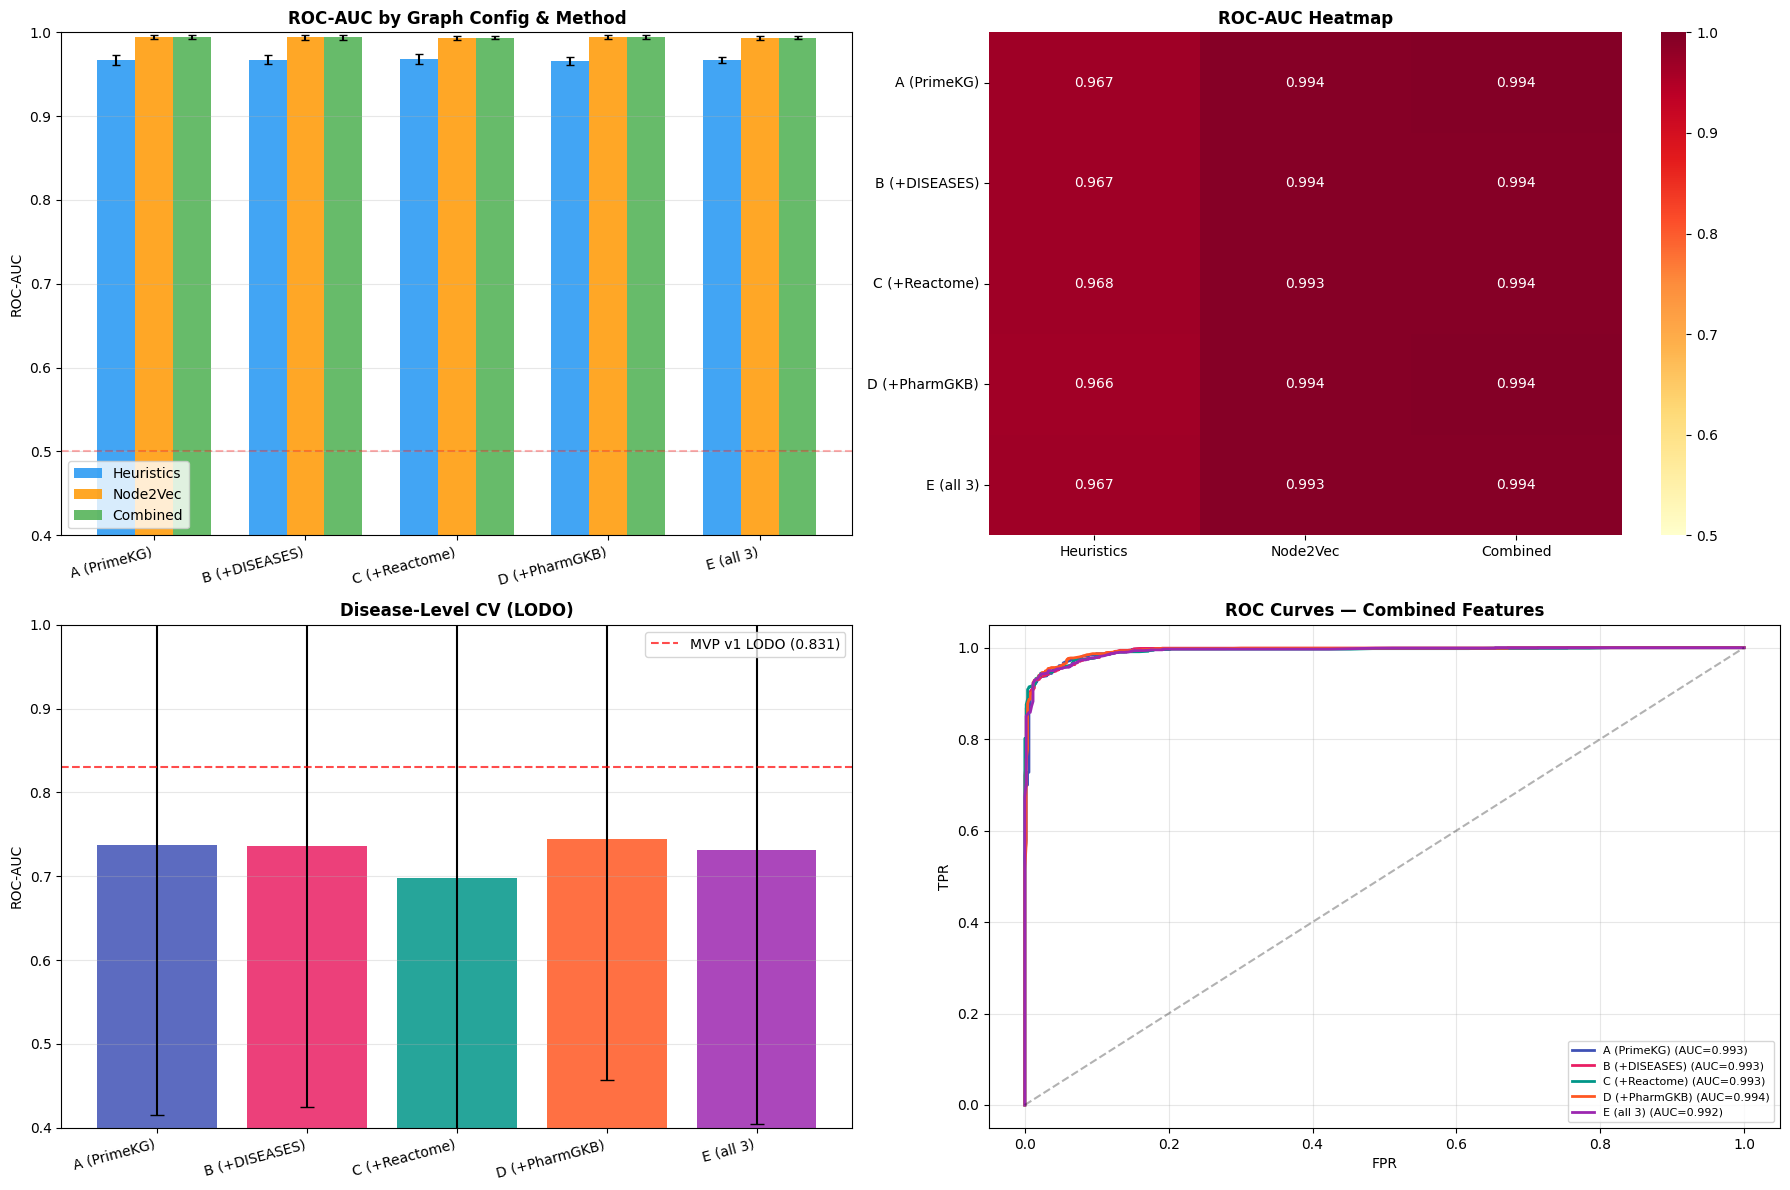

Saved: mvp_v3_results.png


In [19]:
GRAPH_KEYS   = list('ABCDE')
graph_labels = ['A (PrimeKG)', 'B (+DISEASES)', 'C (+Reactome)', 'D (+PharmGKB)', 'E (all 3)']
methods      = ['Heuristics', 'Node2Vec', 'Combined']
colors_method = ['#2196F3', '#FF9800', '#4CAF50']
colors_graph  = ['#3F51B5', '#E91E63', '#009688', '#FF5722', '#9C27B0']

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# ── Bar chart ──────────────────────────────────────────────────────────────
ax = axes[0,0]
x = np.arange(5); width = 0.25
for i, m in enumerate(methods):
    vals = [results_df.loc[f'Graph {g} - {m}','roc_auc_mean']
            if f'Graph {g} - {m}' in results_df.index else 0 for g in GRAPH_KEYS]
    errs = [results_df.loc[f'Graph {g} - {m}','roc_auc_std']
            if f'Graph {g} - {m}' in results_df.index else 0 for g in GRAPH_KEYS]
    ax.bar(x + i*width, vals, width, yerr=errs, label=m, color=colors_method[i], capsize=3, alpha=0.85)
ax.set_ylabel('ROC-AUC')
ax.set_title('ROC-AUC by Graph Config & Method', fontweight='bold')
ax.set_xticks(x + width); ax.set_xticklabels(graph_labels, rotation=15, ha='right')
ax.legend(); ax.set_ylim([0.4, 1.0])
ax.axhline(y=0.5, color='red', linestyle='--', alpha=0.3); ax.grid(axis='y', alpha=0.3)

# ── Heatmap ────────────────────────────────────────────────────────────────
ax = axes[0,1]
hm = np.zeros((5, 3))
for i, g in enumerate(GRAPH_KEYS):
    for j, m in enumerate(methods):
        k = f'Graph {g} - {m}'
        hm[i,j] = results_df.loc[k,'roc_auc_mean'] if k in results_df.index else 0
sns.heatmap(hm, annot=True, fmt='.3f', cmap='YlOrRd',
            xticklabels=methods, yticklabels=graph_labels, ax=ax, vmin=0.5, vmax=1.0)
ax.set_title('ROC-AUC Heatmap', fontweight='bold')

# ── LODO bars ──────────────────────────────────────────────────────────────
ax = axes[1,0]
lm = [lodo_results[g]['roc_auc'].mean() if g in lodo_results else 0 for g in GRAPH_KEYS]
ls = [lodo_results[g]['roc_auc'].std()  if g in lodo_results else 0 for g in GRAPH_KEYS]
ax.bar(graph_labels, lm, yerr=ls, color=colors_graph, capsize=5, alpha=0.85)
ax.axhline(y=0.831, color='red', linestyle='--', alpha=0.7, label='MVP v1 LODO (0.831)')
ax.set_ylabel('ROC-AUC'); ax.set_title('Disease-Level CV (LODO)', fontweight='bold')
ax.legend(); ax.set_ylim([0.4, 1.0]); ax.grid(axis='y', alpha=0.3)
ax.set_xticklabels(graph_labels, rotation=15, ha='right')

# ── ROC curves ─────────────────────────────────────────────────────────────
ax = axes[1,1]
for (gn, hdf, edf), col in zip(graph_data, colors_graph):
    Xc = np.hstack([hdf.values, edf.values])
    Xtr,Xte,ytr,yte = train_test_split(Xc, y, test_size=0.2, random_state=42, stratify=y)
    rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    rf.fit(Xtr, ytr)
    yp = rf.predict_proba(Xte)[:,1]
    fpr, tpr, _ = roc_curve(yte, yp)
    lbl = graph_labels[GRAPH_KEYS.index(gn)]
    ax.plot(fpr, tpr, color=col, lw=2, label=f'{lbl} (AUC={auc(fpr,tpr):.3f})')
ax.plot([0,1],[0,1],'k--',alpha=0.3)
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('ROC Curves — Combined Features', fontweight='bold')
ax.legend(loc='lower right', fontsize=8); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('mvp_v3_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: mvp_v3_results.png")


## 11. Summary & Key Takeaways

In [20]:
print("=" * 70)
print(f"DATASET: {len(df_dataset)} samples  ({N_DISEASES} diseases, {N_DRUGS} drugs)")
print(f"\nGRAPH CONFIGS:")
for name, G in graphs.items():
    print(f"  {name:<20} {G.number_of_nodes():>8,} nodes  {G.number_of_edges():>10,} edges")
print(f"\nEXTERNAL EDGES ADDED:")
print(f"  DISEASES:  {diseases_edges_added:,}")
print(f"  Reactome:  {reactome_edges_added:,}")
print(f"  PharmGKB:  {pharmgkb_edges_added:,}")
print(f"\n5-FOLD CV (top 10):")
print(results_df[['roc_auc_mean','roc_auc_std','accuracy_mean','f1_mean']].head(10).to_string())
print(f"\nLODO (Combined features, 50 diseases):")
for g in GRAPH_KEYS:
    if g in lodo_results and len(lodo_results[g])>0:
        lr = lodo_results[g]
        print(f"  Graph {g}: AUC={lr['roc_auc'].mean():.3f}±{lr['roc_auc'].std():.3f}")

best_v3 = results_df.iloc[0]
best_bg = {g: results_df[results_df.index.str.contains(f'Graph {g}')]['roc_auc_mean'].max()
           for g in GRAPH_KEYS}
bg = max(best_bg, key=best_bg.get)
print(f"\nKEY TAKEAWAYS:")
print(f"  1. Best graph: Graph {bg} (AUC={best_bg[bg]:.3f})")
for src, gkey, label in [('DISEASES','B','DISEASES'), ('Reactome','C','Reactome'), ('PharmGKB','D','PharmGKB')]:
    diff = best_bg.get(gkey,0) - best_bg.get('A',0)
    tag = 'HELPS' if diff>0.005 else 'HURTS' if diff<-0.005 else 'minimal effect'
    print(f"  2. {label}: {tag} ({diff:+.3f} vs baseline A)")
combo_diff = best_bg.get('E',0) - best_bg.get('A',0)
tag = 'HELPS' if combo_diff>0.005 else 'HURTS' if combo_diff<-0.005 else 'minimal effect'
print(f"  3. Combined (E): {tag} ({combo_diff:+.3f} vs baseline A)")
method_best = {m: results_df[results_df.index.str.contains(m)]['roc_auc_mean'].max() for m in methods}
bm = max(method_best, key=method_best.get)
print(f"  4. Best method: {bm} (AUC={method_best[bm]:.3f})")

RESULTS['best_v3'] = best_v3['roc_auc_mean']
with open('mvp_v3_results.pkl', 'wb') as f:
    pickle.dump(RESULTS, f)
print("\nSaved: mvp_v3_results.pkl")
print("=" * 70)


DATASET: 14824 samples  (328 diseases, 1000 drugs)

GRAPH CONFIGS:
  A (PrimeKG)            31,508 nodes     915,564 edges
  B (+DISEASES)          31,806 nodes     920,400 edges
  C (+Reactome)          34,411 nodes   1,049,762 edges
  D (+PharmGKB)          31,601 nodes     922,895 edges
  E (all 3)              34,735 nodes   1,061,929 edges

EXTERNAL EDGES ADDED:
  DISEASES:  4,836
  Reactome:  134,198
  PharmGKB:  7,331

5-FOLD CV (top 10):
                    roc_auc_mean  roc_auc_std  accuracy_mean   f1_mean
name                                                                  
Graph D - Combined      0.994450     0.002269       0.964787  0.973083
Graph A - Combined      0.994303     0.002343       0.962494  0.971322
Graph A - Node2Vec      0.994053     0.002253       0.960874  0.970129
Graph D - Node2Vec      0.994047     0.002275       0.964248  0.972631
Graph B - Combined      0.993942     0.002612       0.963168  0.971820
Graph B - Node2Vec      0.993922     0.002521       0